In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Maternal Health Risk Data Set.csv")
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [5]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(562)

In [7]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
670,10,100,50,6.0,99.0,70,mid risk
849,10,100,50,6.0,99.0,70,mid risk
552,12,90,60,7.5,102.0,60,low risk
940,12,90,60,7.5,102.0,60,low risk
543,12,90,60,7.5,102.0,66,low risk
...,...,...,...,...,...,...,...
553,60,120,85,15.0,98.0,60,mid risk
772,60,120,85,15.0,98.0,60,mid risk
818,60,120,85,15.0,98.0,60,mid risk
114,63,140,90,15.0,98.0,90,high risk


In [8]:
features = df.columns.drop("RiskLevel")
df.duplicated(subset=features).sum()

np.int64(598)

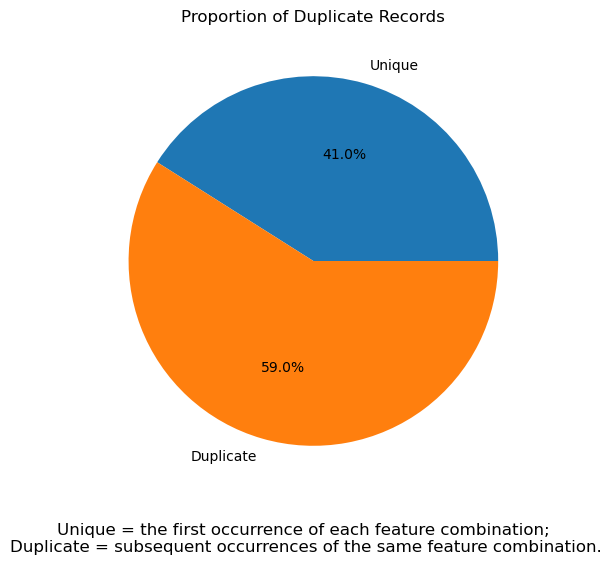

In [9]:
duplicate_count = df.duplicated(subset=features).sum()
unique_count = len(df) - duplicate_count

labels = ["Unique", "Duplicate"]
sizes = [unique_count, duplicate_count]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
)

plt.figtext(
    0.5, 0.01,
    "Unique = the first occurrence of each feature combination; \n"
    "Duplicate = subsequent occurrences of the same feature combination.",
    ha="center",
    fontsize=12
)

plt.title("Proportion of Duplicate Records")
plt.show()

In [10]:
df.groupby(list(features))["RiskLevel"].nunique().value_counts()

RiskLevel
1    381
2     34
3      1
Name: count, dtype: int64

**label inconsistency**: 
- identical feature combinations can have different `RiskLevel` labels. 
- This may indicate data quality issues and could make it harder for classification models to learn the relationship between features and target.

In [11]:
duplicate_rate = df.duplicated().mean()
print(f"Duplicate rate: {duplicate_rate:.2%}")

Duplicate rate: 55.42%


In [12]:
profile_counts = (
    df.groupby(list(features))
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

print(profile_counts.head(20))
print("Total observations:", len(df))
print("Unique profiles:", len(profile_counts))
print("Profiles occurring >1 time:", (profile_counts["count"] > 1).sum())

     Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  count
109   19         120           80   7.0      98.0         70     34
354   48         120           80  11.0      98.0         88     24
270   31         120           60   6.1      98.0         76     20
391   55         140           95  19.0      98.0         77     10
332   40         160          100  19.0      98.0         77     10
282   32         140           90  18.0      98.0         88      9
368   50         130          100  16.0      98.0         75      9
406   60         120           85  15.0      98.0         60      9
328   40         120           95  11.0      98.0         80      9
376   54         140          100  15.0      98.0         66      9
68    17          85           60   9.0     102.0         86      7
336   42         120           80   7.5      98.0         70      7
278   32         120           90   7.5      98.0         70      7
251   29         130           70   7.5      98.

### Data Quality

* The dataset contains a substantial number of duplicate observations, with **562 exact duplicate rows** identified.
* Duplicate feature combinations were even more common (**598 observations**)
* Some identical physiological measurements were assigned different risk levels,  **34 feature combinations were associated with two different RiskLevel classes, while one combination was associated with all three RiskLevel classes**.


Is the data reliable??? 



In [13]:
for col in features:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print("Values:", sorted(df[col].unique())[:50])


Age
Unique values: 50
Values: [np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(54), np.int64(55), np.int64(56), np.int64(59), np.int64(60), np.int64(62), np.int64(63), np.int64(65), np.int64(66), np.int64(70)]

SystolicBP
Unique values: 19
Values: [np.int64(70), np.int64(75), np.int64(76), np.int64(78), np.int64(80), np.int64(83), np.int64(85), np.int64(90), np.int64(95), np.int64(99), np.int64(100), np.int64(110), np.int64(115), np.int64(120), np.int64(129), np.int64(130),

* The dataset uses relatively coarse measurement resolution.
* Also we can see some extreme anomalous values. 

In [14]:
# Observed duplicate count
observed = df.duplicated(subset=features).sum()

n_simulations = 5000
simulated_duplicates = []

for _ in range(n_simulations):

    simulated = df[features].copy()

    # Shuffle each variable independently
    for col in features:
        simulated[col] = np.random.permutation(
            simulated[col].values
        )

    # Count duplicated feature combinations
    duplicates = simulated.duplicated().sum()
    simulated_duplicates.append(duplicates)

simulated_duplicates = np.array(simulated_duplicates)

# Summary
mean_sim = simulated_duplicates.mean()
median_sim = np.median(simulated_duplicates)
lower = np.percentile(simulated_duplicates, 2.5)
upper = np.percentile(simulated_duplicates, 97.5)

print("Observed duplicates:", observed)
print("Simulated mean:", mean_sim)
print("Simulated median:", median_sim)
print(f"95% simulation interval: {lower:.0f} - {upper:.0f}")

# Empirical p-value
p_value = np.mean(simulated_duplicates >= observed)

print("Empirical p-value:", p_value)

Observed duplicates: 598
Simulated mean: 4.1726
Simulated median: 4.0
95% simulation interval: 1 - 8
Empirical p-value: 0.0


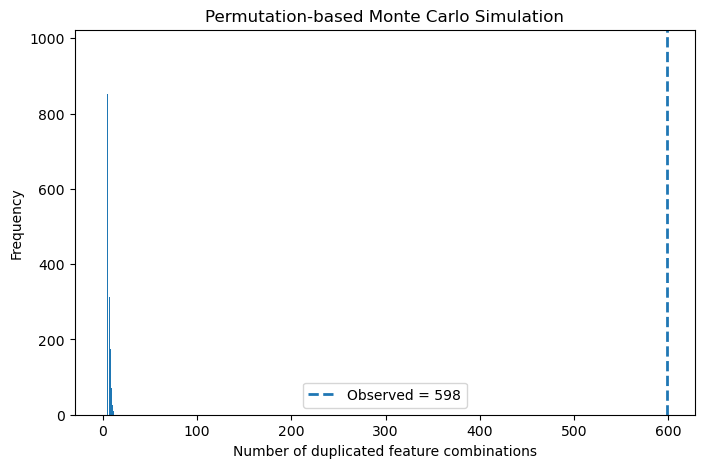

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(simulated_duplicates, bins=30)

plt.axvline(
    observed,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {observed}"
)

plt.xlabel("Number of duplicated feature combinations")
plt.ylabel("Frequency")
plt.title("Permutation-based Monte Carlo Simulation")
plt.legend()

plt.show()

**The extensive repetition in the observed dataset is not explained by the marginal distributions and discrete measurement values alone.**

- might lead to train/test leakage, maybe delete before prediction?

In [16]:
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

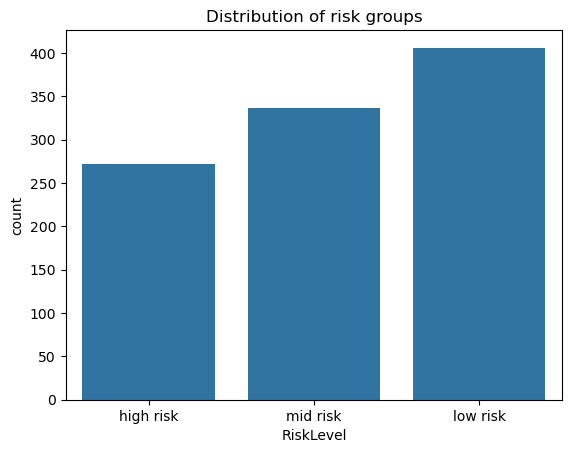

In [17]:
sns.countplot(data=df, x="RiskLevel",order=["high risk", "mid risk", "low risk"])
plt.title("Distribution of risk groups")
plt.show()

### Key Findings

- **No missing values** were identified in the dataset.
- The **RiskLevel** classes are relatively evenly distributed(but need to recheck after removing the duplicates)

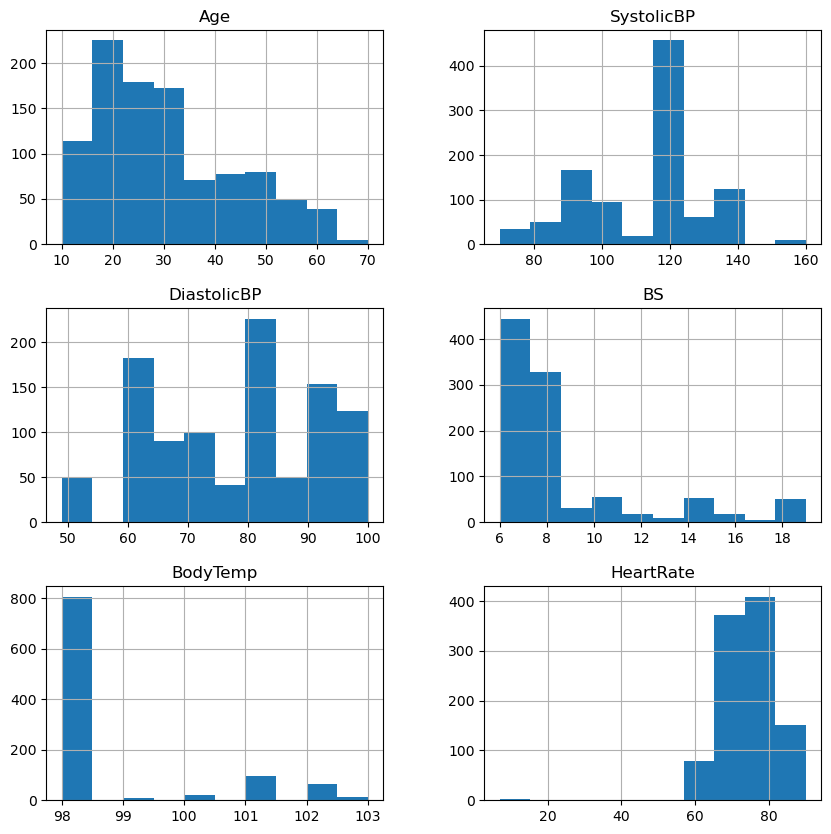

In [18]:
df.hist(figsize = (10,10))
plt.show()

In [441]:
df[features].skew()

Age            0.783063
SystolicBP    -0.251189
DiastolicBP   -0.048441
BS             1.868203
BodyTemp       1.750988
HeartRate     -1.043525
dtype: float64

**Key Findings**
- BS, BodyTemp and HeartRate is highly skewed, with isolated anomalous heart rate values (HeartRate below 20 bpm, Age 10/70).

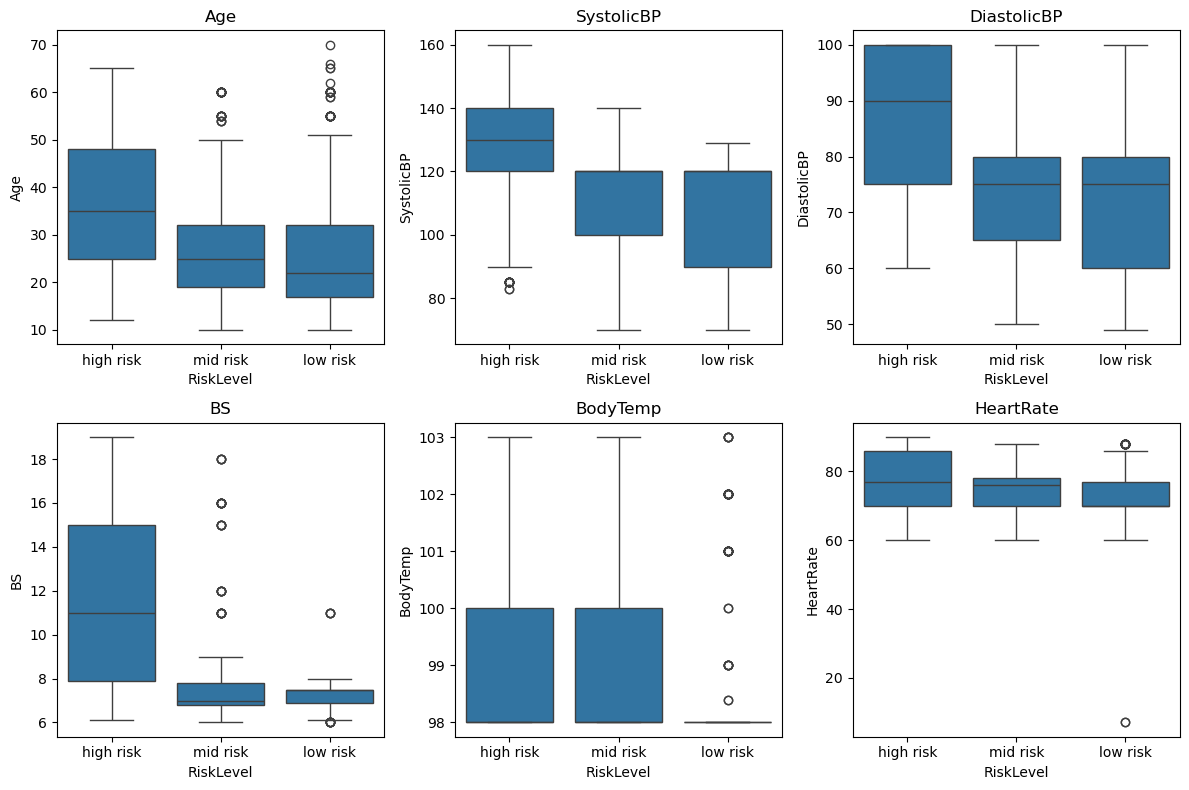

In [442]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, feature in zip(axes.flat, features):
    sns.boxplot(data=df, x="RiskLevel", y=feature, ax=ax, order=["high risk", "mid risk", "low risk"])
    ax.set_title(feature)

plt.tight_layout()

* The boxplots show clear differences in the distributions across the three risk groups. 

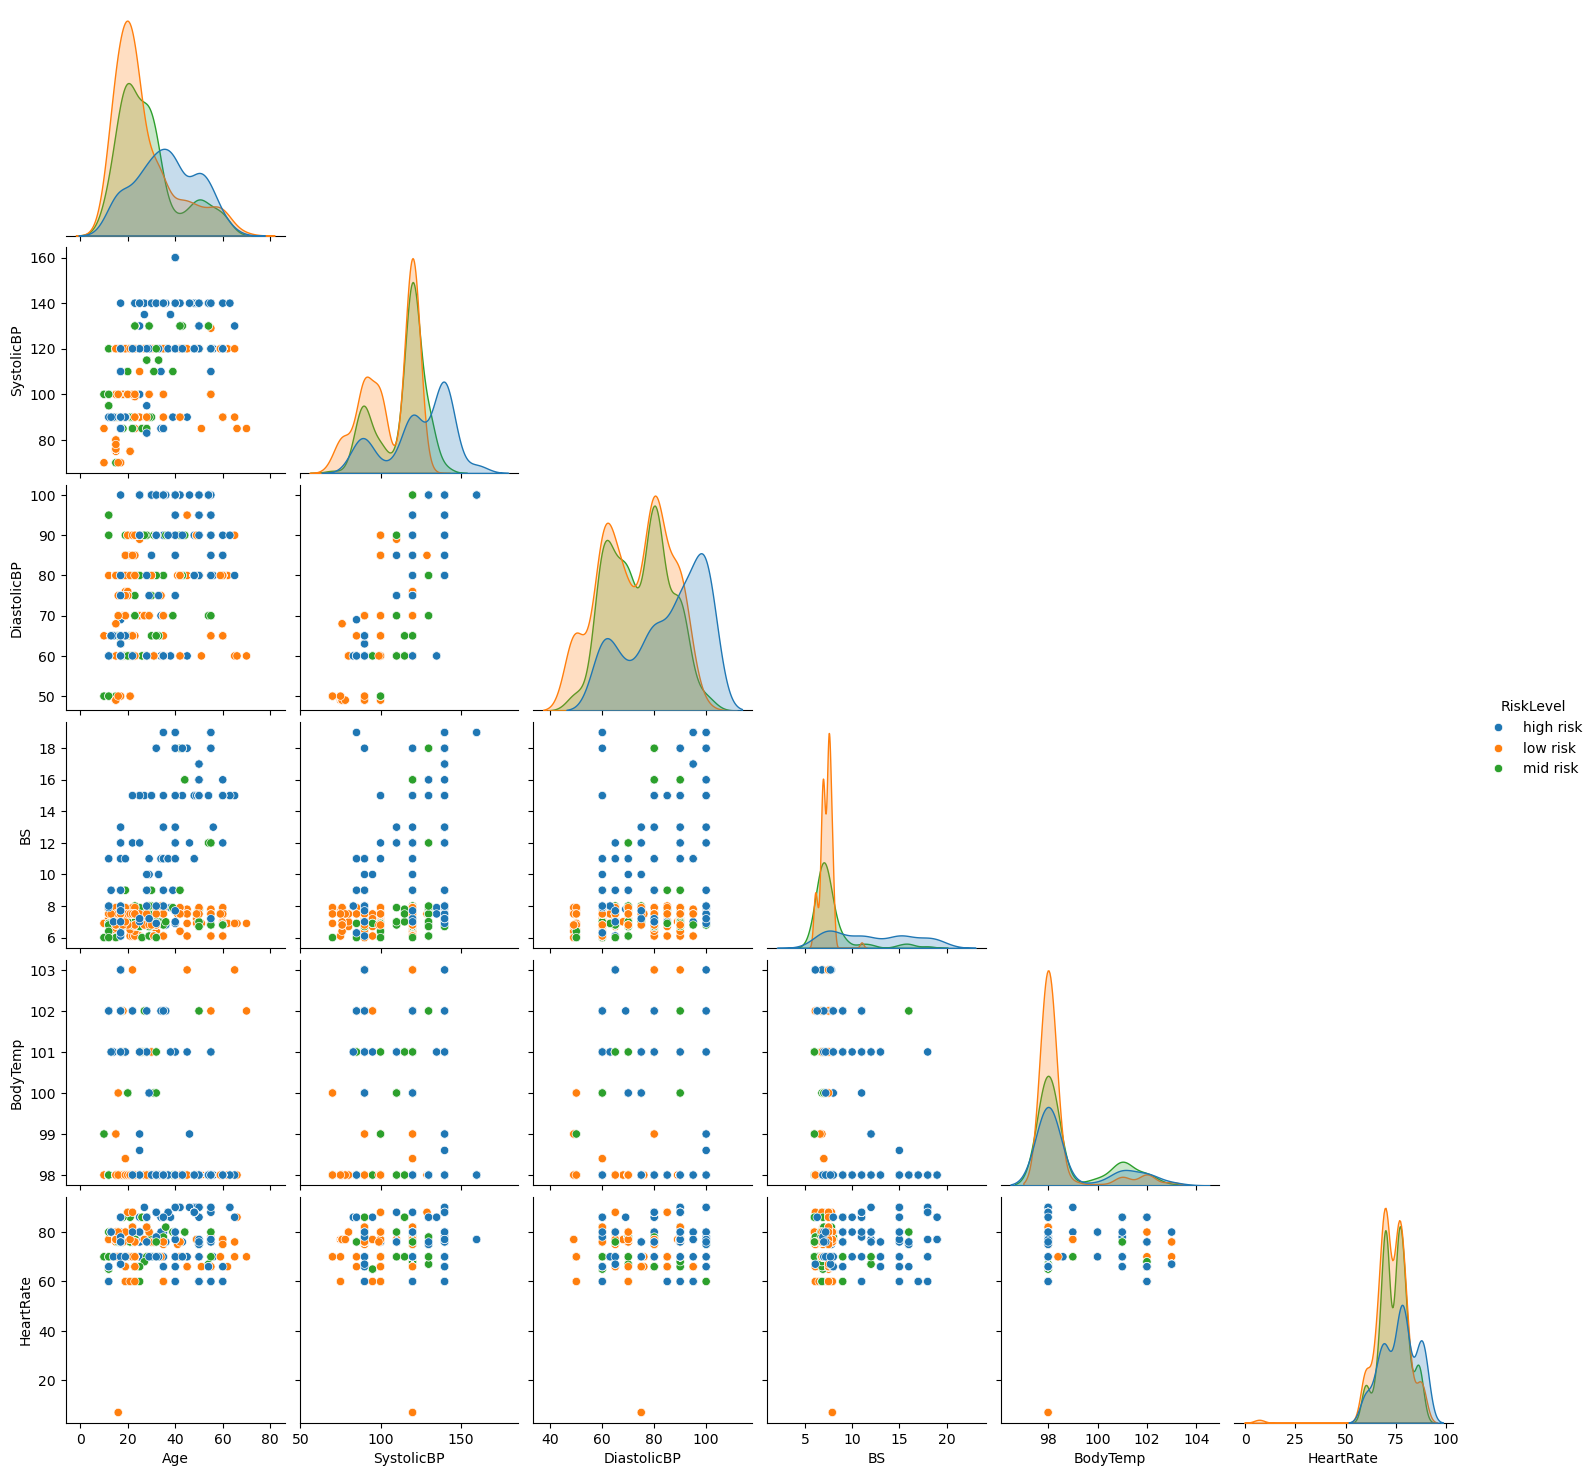

In [443]:
sns.pairplot(
    df,
    vars=features,
    hue="RiskLevel",
    corner=True
)
plt.show()

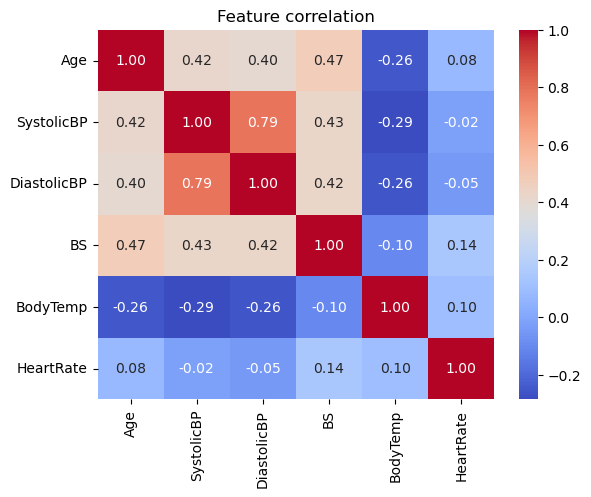

In [444]:
corr = df[features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature correlation")
plt.show()

**Correlation**
- Moderate correlations were observed between blood pressure and BS, BS and age, and blood pressure and age.
- A very strong correlation was observed between SBP and DBP.

May contain overlapping information, which could be relevant to feature selection and multicollinearity in some predictive models.

* How about using **MAP**?

In [445]:
df["MAP"] = (
    df["SystolicBP"] + 2 * df["DiastolicBP"]
) / 3

features_map = df.columns.drop(["SystolicBP","DiastolicBP","RiskLevel"])
features_map

Index(['Age', 'BS', 'BodyTemp', 'HeartRate', 'MAP'], dtype='object')

**Fix the outliers.**

In [449]:
heart_rate_median = df["HeartRate"].median()
df.loc[df["HeartRate"] == 7, "HeartRate"] = heart_rate_median

**Question:**
* How should we handle values that look abnormal but may still be genuine? 
* For example, if a pregnant woman is recorded as being 10 or 70 years old, should we remove or replace these values, or keep them in the dataset?

**Remove the duplicates.**

In [451]:
df_clean = df.drop_duplicates()

In [452]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 452 entries, 0 to 705
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          452 non-null    int64  
 1   SystolicBP   452 non-null    int64  
 2   DiastolicBP  452 non-null    int64  
 3   BS           452 non-null    float64
 4   BodyTemp     452 non-null    float64
 5   HeartRate    452 non-null    int64  
 6   RiskLevel    452 non-null    object 
 7   MAP          452 non-null    float64
dtypes: float64(3), int64(4), object(1)
memory usage: 31.8+ KB


In [453]:
df_clean.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,MAP
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000
mean,29.194690,110.553097,75.418142,8.346173,98.692478,74.101770,87.129794
std,13.767379,17.872282,13.754578,2.829209,1.410897,7.522224,14.348764
min,10.000000,70.000000,49.000000,6.000000,98.000000,60.000000,56.666667
25%,19.000000,90.000000,65.000000,6.900000,98.000000,70.000000,73.333333
50%,25.000000,120.000000,80.000000,7.500000,98.000000,76.000000,90.333333
75%,35.000000,120.000000,86.000000,7.900000,98.000000,80.000000,96.666667
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,120.000000


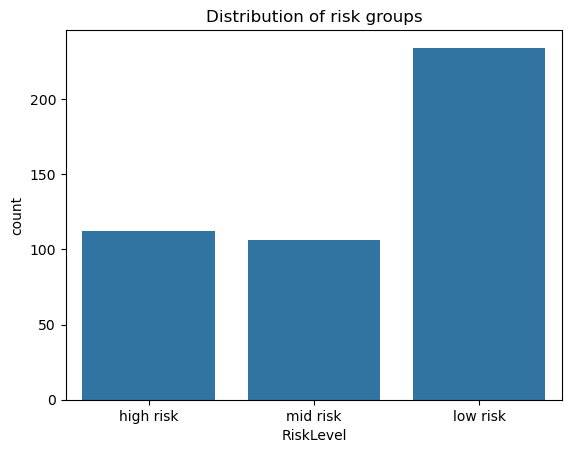

In [454]:
sns.countplot(data=df_clean, x="RiskLevel",order=["high risk", "mid risk", "low risk"])
plt.title("Distribution of risk groups")
plt.show()

**A quick run to check the performance of 3 basic models**

In [463]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


def create_models():
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=1000))
        ]),
        
        "Decision Tree": Pipeline([
            ("classifier", DecisionTreeClassifier(random_state=42))
        ]),
        
        "Random Forest": Pipeline([
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                class_weight="balanced"
            ))
        ])
    }



In [468]:
datasets = [
    (df[features], df["RiskLevel"]),
    (df[features_map], df["RiskLevel"]),
    (df_clean[features], df_clean["RiskLevel"]),
    (df_clean[features_map], df_clean["RiskLevel"])
]


In [469]:
all_models = []
test_sets = []

for X, y in datasets:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    models = create_models()

    for model in models.values():
        model.fit(X_train, y_train)

    all_models.append(models)
    test_sets.append((X_test, y_test))

In [470]:
all_models

[{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                  ('classifier', LogisticRegression(max_iter=1000))]),
  'Decision Tree': Pipeline(steps=[('classifier', DecisionTreeClassifier(random_state=42))]),
  'Random Forest': Pipeline(steps=[('classifier',
                   RandomForestClassifier(class_weight='balanced',
                                          random_state=42))])},
 {'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                  ('classifier', LogisticRegression(max_iter=1000))]),
  'Decision Tree': Pipeline(steps=[('classifier', DecisionTreeClassifier(random_state=42))]),
  'Random Forest': Pipeline(steps=[('classifier',
                   RandomForestClassifier(class_weight='balanced',
                                          random_state=42))])},
 {'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                  ('classifier', LogisticRegression(max_iter=1000))]),
  'Decision Tree': Pipel

In [ ]:
test_sets

[(     Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
  148   12          95           60  6.70      98.0         77
  837   19         120           85  9.00      98.0         60
  17    25         140          100  7.01      98.0         80
  260   16         100           70  6.90      98.0         80
  396   20         120           75  7.80      98.0         70
  ..   ...         ...          ...   ...       ...        ...
  887   20         120           75  6.80      98.0         70
  606   55         100           65  7.50      98.0         66
  922   17          85           60  7.50     102.0         86
  160   35         120           80  7.50      98.0         80
  608   35         100           70  7.50      98.0         66
  
  [203 rows x 6 columns],
  148     low risk
  837     mid risk
  17     high risk
  260     low risk
  396     low risk
           ...    
  887     low risk
  606     low risk
  922     low risk
  160     low risk
  608     low risk
  Name

In [474]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

dataset_names = [
    "Original",
    "MAP",
    "Clean",
    "Clean + MAP"
]

results = []

for dataset_name, models, (X_test_current, y_test_current) in zip(
    dataset_names,
    all_models,
    test_sets
):
    print(f"---{dataset_name}---")

    for name, model in models.items():

        y_pred = model.predict(X_test_current)

        accuracy = accuracy_score(y_test_current, y_pred)
        weighted_f1 = f1_score(
            y_test_current,
            y_pred,
            average="weighted"
        )

        print(
            f"{name}: "
            f"accuracy = {accuracy:.3f}, "
            f"weighted F1 = {weighted_f1:.3f}"
        )

        results.append({
            "Dataset": dataset_name,
            "Model": name,
            "Accuracy": accuracy,
            "Weighted F1": weighted_f1
        })

results_df = pd.DataFrame(results)


---Original---
Logistic Regression: accuracy = 0.616, weighted F1 = 0.600
Decision Tree: accuracy = 0.842, weighted F1 = 0.844
Random Forest: accuracy = 0.857, weighted F1 = 0.858
---MAP---
Logistic Regression: accuracy = 0.621, weighted F1 = 0.580
Decision Tree: accuracy = 0.837, weighted F1 = 0.840
Random Forest: accuracy = 0.857, weighted F1 = 0.859
---Clean---
Logistic Regression: accuracy = 0.670, weighted F1 = 0.591
Decision Tree: accuracy = 0.582, weighted F1 = 0.594
Random Forest: accuracy = 0.582, weighted F1 = 0.588
---Clean + MAP---
Logistic Regression: accuracy = 0.659, weighted F1 = 0.566
Decision Tree: accuracy = 0.549, weighted F1 = 0.573
Random Forest: accuracy = 0.571, weighted F1 = 0.578


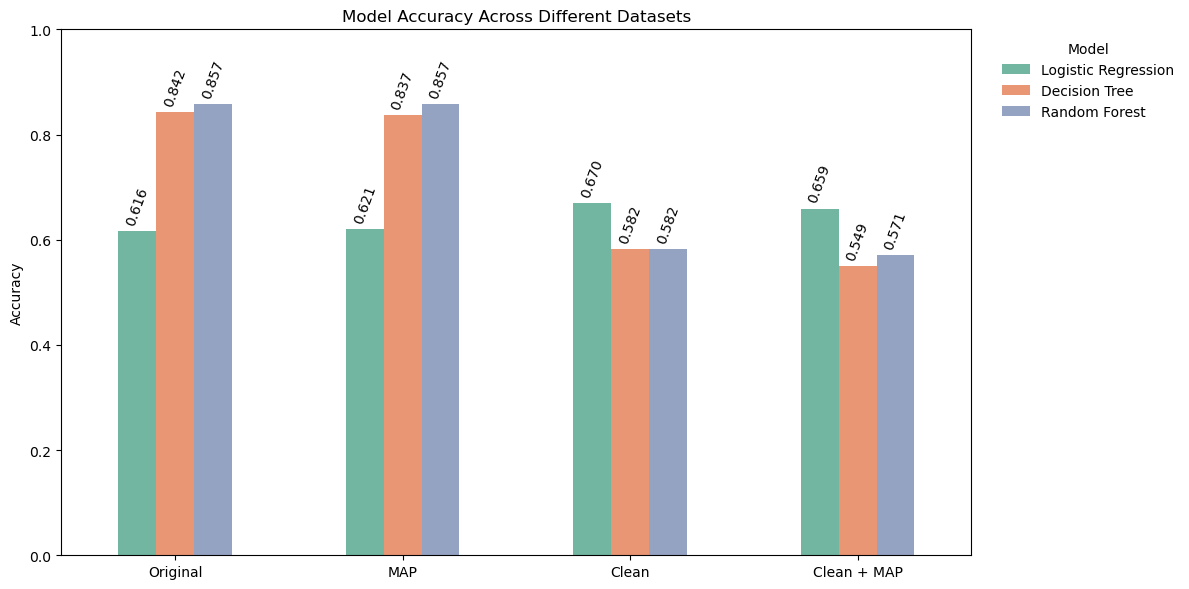

In [479]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Dataset",
    y="Accuracy",
    hue="Model",
    width=0.5,
    palette="Set2"
)

plt.ylim(0, 1)

plt.xlabel("")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Across Different Datasets")

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        rotation=70
    )

plt.tight_layout()
plt.show()

### Choose a Model and Do Finetuning